C:\Users\ashaz\AppData\Local\Temp\ipykernel_79460\799862944.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis', len(processes))


Generating 4 corresponding Gantt Charts...


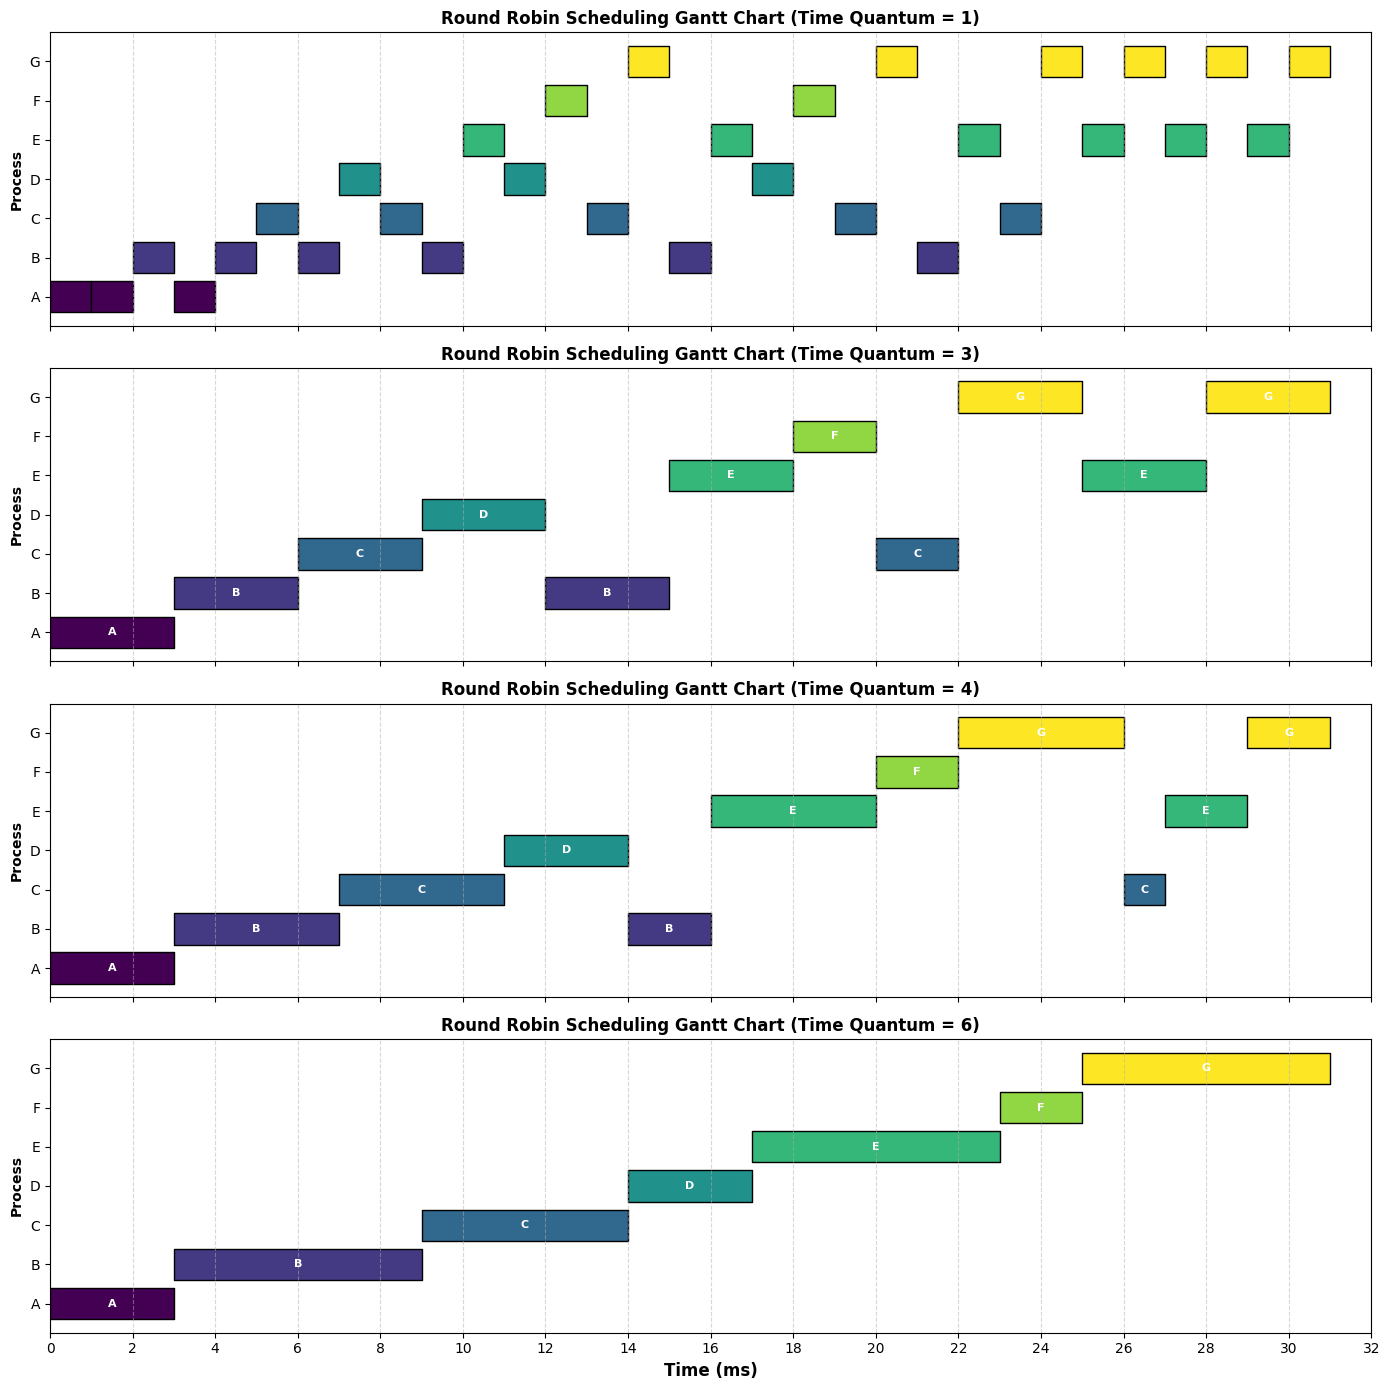

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Simulation function to generate Gantt chart data
def simulate_rr_gantt(job_data, tq):
    # Sorting by arrival is mandatory for RR
    jobs = sorted([dict(j, rem=j['exec']) for j in job_data], key=lambda x: x['arrival'])
    time = 0
    ready_queue = []
    job_index = 0
    completed = 0
    
    gantt_chart_segments = []

    while completed < len(jobs):
        # 1. Add all jobs that arrived by the current time
        while job_index < len(jobs) and jobs[job_index]['arrival'] <= time:
            ready_queue.append(jobs[job_index])
            job_index += 1
            
        if not ready_queue:
            if job_index < len(jobs):
                # Jump time to the next job's arrival
                time = jobs[job_index]['arrival']
                continue
            break
            
        current = ready_queue.pop(0)
        run_time = min(current['rem'], tq)
        
        # Record this continuous segment of CPU time
        gantt_chart_segments.append({
            'name': current['name'],
            'start': time,
            'duration': run_time
        })
        
        time += run_time
        current['rem'] -= run_time
        
        # 2. Add jobs that arrived *during* execution before re-enqueueing the current job
        while job_index < len(jobs) and jobs[job_index]['arrival'] <= time:
            ready_queue.append(jobs[job_index])
            job_index += 1
            
        if current['rem'] > 0:
            ready_queue.append(current)
        else:
            completed += 1
            
    return gantt_chart_segments

# Data from Table 2
processes = [
    {'name': 'A', 'arrival': 0, 'exec': 3},
    {'name': 'B', 'arrival': 2, 'exec': 6},
    {'name': 'C', 'arrival': 5, 'exec': 5},
    {'name': 'D', 'arrival': 6, 'exec': 3},
    {'name': 'E', 'arrival': 8, 'exec': 6},
    {'name': 'F', 'arrival': 9, 'exec': 2},
    {'name': 'G', 'arrival': 10, 'exec': 6}
]

# The four Time Quantums requested
time_quantums = [1, 3, 4, 6]

# Define Y-positions for each process (Top to Bottom for clarity)
y_map = {
    'G': 60,
    'F': 50,
    'E': 40,
    'D': 30,
    'C': 20,
    'B': 10,
    'A': 0
}

# Create distinct colors
# I'm using a professional palette suitable for a portfolio
cmap = plt.cm.get_cmap('viridis', len(processes))
color_map = {
    'A': cmap(0), 'B': cmap(1), 'C': cmap(2), 'D': cmap(3),
    'E': cmap(4), 'F': cmap(5), 'G': cmap(6)
}

# Set up the figure with 4 stacked subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
plt.subplots_adjust(hspace=0.4) # Add space between subplots

for i, tq in enumerate(time_quantums):
    ax = axes[i]
    schedule = simulate_rr_gantt(processes, tq)
    
    max_time = 0
    # Draw segments as broken_barh on separate rows
    for segment in schedule:
        name = segment['name']
        start = segment['start']
        dur = segment['duration']
        end = start + dur
        
        if end > max_time:
            max_time = end
            
        # Draw the rectangle with a slight vertical gap (height 8 vs step 10)
        ax.broken_barh([(start, dur)], (y_map[name], 8), 
                       facecolors=color_map[name], edgecolor='black', linewidth=1)
        
        # Optional: Add small label inside the block if it's large enough
        # At TQ=1, this is unreadable, so we filter it out.
        if dur >= 1 and tq > 1:
            ax.text(start + dur/2, y_map[name] + 4, name, 
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')

    # Chart formatting
    ax.set_title(f"Round Robin Scheduling Gantt Chart (Time Quantum = {tq})", 
                 fontweight='bold', fontsize=12)
    
    # Y-Axis (Processes)
    # We want labels exactly in the middle of each process row (step + 4)
    y_ticks = sorted([y + 4 for y in y_map.values()])
    y_labels = sorted(y_map.keys(), key=lambda k: y_map[k])
    
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels)
    ax.set_ylabel("Process", fontweight='bold')
    
    # Grid and X-Axis (Timeline)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    # Add a buffer for max_time so the chart doesn't end abruptly
    ax.set_xlim(0, max_time + 1)
    
    # Ensure all ticks appear (using numpy to generate a full range)
    ax.set_xticks(np.arange(0, max_time + 2, 2))

# Final global X-Axis label on the bottom plot only
axes[-1].set_xlabel("Time (ms)", fontweight='bold', fontsize=12)

# Professional layout
plt.tight_layout()
print("Generating 4 corresponding Gantt Charts...")
plt.show()